In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Invistico_Airline.csv")

# EDA: Invistico Airline (удовлетворённость пассажиров)

**Датасет:** Invistico Airline — опрос пассажиров авиакомпании об удовлетворённости перелётом.
Скачать: https://www.kaggle.com/datasets/yakhyojon/customer-satisfaction-in-airline

Содержит демографию (пол, возраст, тип клиента), параметры рейса (класс, дальность,
задержки вылета/прибытия) и оценки 14 сервисов по шкале 0-5. Таргет - `satisfaction`
(satisfied / neutral or dissatisfied).

In [3]:
df.head()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0


In [4]:
df.tail()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
129875,satisfied,Female,disloyal Customer,29,Personal Travel,Eco,1731,5,5,5,...,2,2,3,3,4,4,4,2,0,0.0
129876,dissatisfied,Male,disloyal Customer,63,Personal Travel,Business,2087,2,3,2,...,1,3,2,3,3,1,2,1,174,172.0
129877,dissatisfied,Male,disloyal Customer,69,Personal Travel,Eco,2320,3,0,3,...,2,4,4,3,4,2,3,2,155,163.0
129878,dissatisfied,Male,disloyal Customer,66,Personal Travel,Eco,2450,3,2,3,...,2,3,3,2,3,2,1,2,193,205.0
129879,dissatisfied,Female,disloyal Customer,38,Personal Travel,Eco,4307,3,4,3,...,3,4,5,5,5,3,3,3,185,186.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Gender                             129880 non-null  object 
 2   Customer Type                      129880 non-null  object 
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  object 
 5   Class                              129880 non-null  object 
 6   Flight Distance                    129880 non-null  int64  
 7   Seat comfort                       129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Food and drink                     129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Inflight wifi service              1298

In [6]:
df.describe()

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [7]:
df.describe(include="object")

,satisfaction,Gender,Customer Type,Type of Travel,Class
count,129880,129880,129880,129880,129880
unique,2,2,2,2,3
top,satisfied,Female,Loyal Customer,Business travel,Business
freq,71087,65899,106100,89693,62160


In [8]:
df.shape

(129880, 23)

In [9]:
df.isnull().sum()

satisfaction                           0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

satisfaction                          object
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival De

In [12]:
df.isna().sum()

satisfaction                           0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

Так как пропусков значений мало, искусственно создадим их в нескольких колонках

In [13]:
mask = np.random.rand(*df['Age'].shape) < 0.3
df.loc[mask, 'Age'] = np.nan
mask = np.random.rand(*df['Class'].shape) < 0.13
df.loc[mask, 'Class'] = np.nan
mask = np.random.rand(*df['Flight Distance'].shape) < 0.01
df.loc[mask, 'Flight Distance'] = np.nan

In [14]:
df.isna().sum()

satisfaction                             0
Gender                                   0
Customer Type                            0
Age                                  39144
Type of Travel                           0
Class                                16756
Flight Distance                       1289
Seat comfort                             0
Departure/Arrival time convenient        0
Food and drink                           0
Gate location                            0
Inflight wifi service                    0
Inflight entertainment                   0
Online support                           0
Ease of Online booking                   0
On-board service                         0
Leg room service                         0
Baggage handling                         0
Checkin service                          0
Cleanliness                              0
Online boarding                          0
Departure Delay in Minutes               0
Arrival Delay in Minutes               393
dtype: int6

In [15]:
df = df.dropna(subset=['Flight Distance'])
df.isna().sum()

satisfaction                             0
Gender                                   0
Customer Type                            0
Age                                  38725
Type of Travel                           0
Class                                16583
Flight Distance                          0
Seat comfort                             0
Departure/Arrival time convenient        0
Food and drink                           0
Gate location                            0
Inflight wifi service                    0
Inflight entertainment                   0
Online support                           0
Ease of Online booking                   0
On-board service                         0
Leg room service                         0
Baggage handling                         0
Checkin service                          0
Cleanliness                              0
Online boarding                          0
Departure Delay in Minutes               0
Arrival Delay in Minutes               389
dtype: int6

In [16]:
print("mean: ", df.dropna(subset=['Age'])['Age'].mean())
print("median: ", df.dropna(subset=['Age'])['Age'].median())
print("max: ", df.dropna(subset=['Age'])['Age'].max())

mean:  39.411323526138915
median:  40.0
max:  85.0


Медиана и Среднее мало отличаются, а значит распределение нормальное. Поэтому без разницы какую стратегию заполнения использовать.

In [17]:
df['Age'] = df["Age"].fillna(df["Age"].mean())

In [18]:
df.mode()

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,39.411324,Business travel,Business,1963.0,3,4,3,...,4,4,4,4,4,4,4,4,0,0.0


Логично предположить, что если данные о задержке прибытия отсутствуют, то задержки не было, либо она была незначительна. Значит заполним Arrival Delay in Minutes значением 0

In [19]:
df['Arrival Delay in Minutes'] =  df["Arrival Delay in Minutes"].fillna(0)

In [20]:
df.isna().sum()

satisfaction                             0
Gender                                   0
Customer Type                            0
Age                                      0
Type of Travel                           0
Class                                16583
Flight Distance                          0
Seat comfort                             0
Departure/Arrival time convenient        0
Food and drink                           0
Gate location                            0
Inflight wifi service                    0
Inflight entertainment                   0
Online support                           0
Ease of Online booking                   0
On-board service                         0
Leg room service                         0
Baggage handling                         0
Checkin service                          0
Cleanliness                              0
Online boarding                          0
Departure Delay in Minutes               0
Arrival Delay in Minutes                 0
dtype: int6

In [21]:
df

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65.000000,Personal Travel,Eco,265.0,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,39.411324,Personal Travel,Business,2464.0,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,39.411324,Personal Travel,Eco,2138.0,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,39.411324,Personal Travel,NaN,623.0,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,39.411324,Personal Travel,Eco,354.0,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,satisfied,Female,disloyal Customer,29.000000,Personal Travel,Eco,1731.0,5,5,5,...,2,2,3,3,4,4,4,2,0,0.0
129876,dissatisfied,Male,disloyal Customer,39.411324,Personal Travel,Business,2087.0,2,3,2,...,1,3,2,3,3,1,2,1,174,172.0
129877,dissatisfied,Male,disloyal Customer,69.000000,Personal Travel,Eco,2320.0,3,0,3,...,2,4,4,3,4,2,3,2,155,163.0
129878,dissatisfied,Male,disloyal Customer,66.000000,Personal Travel,Eco,2450.0,3,2,3,...,2,3,3,2,3,2,1,2,193,205.0


In [22]:
df['Class'] =  df["Class"].fillna(df["Class"].mode())

In [23]:
df = pd.read_csv("Invistico_Airline.csv")
df['Class'] = df['Class'].fillna(df['Class'].mode().iloc[0])
df['Class'].isna().sum()

np.int64(0)

In [24]:
num_cols = df.select_dtypes(include='number').columns

stats = pd.DataFrame({
    'min':    df[num_cols].min(),
    'max':    df[num_cols].max(),
    'mean':   df[num_cols].mean(),
    'median': df[num_cols].median(),
    'mode':   df[num_cols].mode().iloc[0],
})
stats

,min,max,mean,median,mode
Age,7.0,85.0,39.427957,40.0,39.0
Flight Distance,50.0,6951.0,1981.409055,1925.0,1963.0
Seat comfort,0.0,5.0,2.838597,3.0,3.0
Departure/Arrival time convenient,0.0,5.0,2.990645,3.0,4.0
Food and drink,0.0,5.0,2.851994,3.0,3.0
Gate location,0.0,5.0,2.990422,3.0,3.0
Inflight wifi service,0.0,5.0,3.249130,3.0,4.0
Inflight entertainment,0.0,5.0,3.383477,4.0,4.0
Online support,0.0,5.0,3.519703,4.0,4.0
Ease of Online booking,0.0,5.0,3.472105,4.0,4.0


In [25]:
# mask = np.random.rand(*df['Type of Travel'].shape) < 0.25
# df.loc[mask, 'Type of Travel'] = np.nan
# import sklearn
# from sklearn.impute import KNNImputer

# imputer = KNNImputer(n_neighbors=5)
# df_imputed = imputer.fit_transform(df)

In [26]:
df[num_cols].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).T

,0.05,0.25,0.50,0.75,0.95
Age,15.0,27.0,40.0,51.0,64.0
Flight Distance,341.0,1359.0,1925.0,2544.0,3831.0
Seat comfort,1.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,0.0,2.0,3.0,4.0,5.0
Food and drink,1.0,2.0,3.0,4.0,5.0
Gate location,1.0,2.0,3.0,4.0,5.0
Inflight wifi service,1.0,2.0,3.0,4.0,5.0
Inflight entertainment,1.0,2.0,4.0,4.0,5.0
Online support,1.0,3.0,4.0,5.0,5.0
Ease of Online booking,1.0,2.0,4.0,5.0,5.0


In [27]:
df.select_dtypes(include='number').std()

Age                                    15.119360
Flight Distance                      1027.115606
Seat comfort                            1.392983
Departure/Arrival time convenient       1.527224
Food and drink                          1.443729
Gate location                           1.305970
Inflight wifi service                   1.318818
Inflight entertainment                  1.346059
Online support                          1.306511
Ease of Online booking                  1.305560
On-board service                        1.270836
Leg room service                        1.292226
Baggage handling                        1.156483
Checkin service                         1.260582
Cleanliness                             1.151774
Online boarding                         1.298715
Departure Delay in Minutes             38.071126
Arrival Delay in Minutes               38.465650
dtype: float64

In [28]:
df.select_dtypes(include='number').var()

Age                                  2.285950e+02
Flight Distance                      1.054966e+06
Seat comfort                         1.940402e+00
Departure/Arrival time convenient    2.332414e+00
Food and drink                       2.084355e+00
Gate location                        1.705557e+00
Inflight wifi service                1.739280e+00
Inflight entertainment               1.811875e+00
Online support                       1.706970e+00
Ease of Online booking               1.704486e+00
On-board service                     1.615023e+00
Leg room service                     1.669848e+00
Baggage handling                     1.337454e+00
Checkin service                      1.589068e+00
Cleanliness                          1.326583e+00
Online boarding                      1.686659e+00
Departure Delay in Minutes           1.449411e+03
Arrival Delay in Minutes             1.479606e+03
dtype: float64

In [29]:
print("Skewness: \n", df.select_dtypes(include='number').skew())
print("------------------------------------------------")
print("Kurtosis: \n", df.select_dtypes(include='number').kurt())

Skewness: 
 Age                                 -0.003606
Flight Distance                      0.466748
Seat comfort                        -0.091861
Departure/Arrival time convenient   -0.252282
Food and drink                      -0.116813
Gate location                       -0.053064
Inflight wifi service               -0.191123
Inflight entertainment              -0.604828
Online support                      -0.575365
Ease of Online booking              -0.491720
On-board service                    -0.505270
Leg room service                    -0.496440
Baggage handling                    -0.743037
Checkin service                     -0.392442
Cleanliness                         -0.756001
Online boarding                     -0.366496
Departure Delay in Minutes           6.821980
Arrival Delay in Minutes             6.670125
dtype: float64
------------------------------------------------
Kurtosis: 
 Age                                   -0.719140
Flight Distance                     

Ассиметрия в дальности полетов может быть связана с географией мест, где собиралась статистика. Многие колонки со значениями, которые выражают оценку качества услуги имеют значение равное 1, потому что оценки распределены равномерно

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

le_list = ['Gender', 'satisfaction', 'Customer Type', 'Type of Travel', 'Class']
for col in le_list:
    df[col] = le.fit_transform(df[col])


In [31]:
service_cols = ['Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink', 'Gate location',
       'Inflight wifi service', 'Inflight entertainment', 'Online support',
       'Ease of Online booking', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding']

df['has_zero_rating'] = (df[service_cols] == 0).any(axis=1).astype(int) #новый признак, 1 - если есть хотя бы одна нулевая оценка

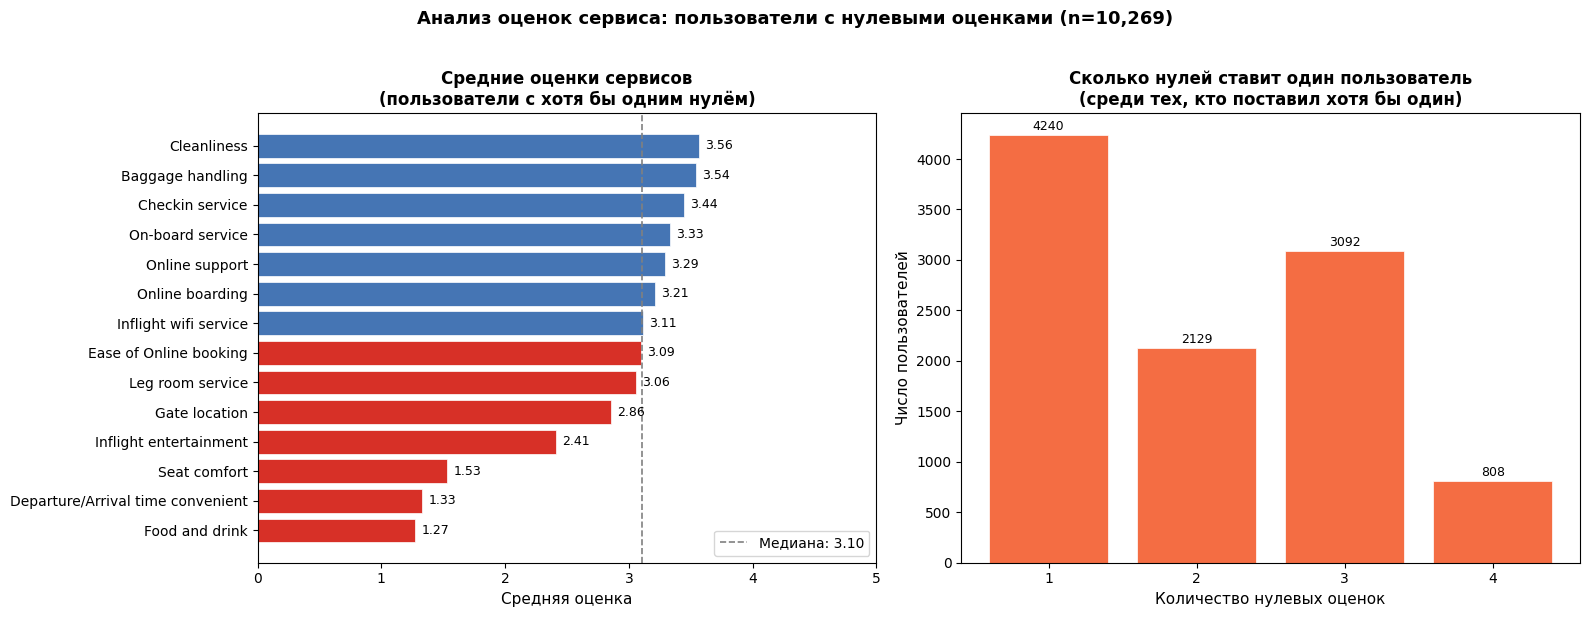

In [32]:
service_cols = [
    'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink',
    'Gate location', 'Inflight wifi service', 'Inflight entertainment',
    'Online support', 'Ease of Online booking', 'On-board service',
    'Leg room service', 'Baggage handling', 'Checkin service',
    'Cleanliness', 'Online boarding'
]

# Фильтруем только тех, кто поставил хотя бы один ноль
zero_raters = df[df['has_zero_rating'] == 1]

# Считаем среднюю оценку по каждому сервису
mean_scores = zero_raters[service_cols].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: средние оценки по каждому сервису ---
colors = ['#d73027' if v < mean_scores.median() else '#4575b4' for v in mean_scores]
bars = axes[0].barh(mean_scores.index, mean_scores.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].axvline(mean_scores.median(), color='gray', linestyle='--', linewidth=1.2, label=f'Медиана: {mean_scores.median():.2f}')
axes[0].set_xlabel('Средняя оценка', fontsize=11)
axes[0].set_title('Средние оценки сервисов\n(пользователи с хотя бы одним нулём)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, 5)

for bar, val in zip(bars, mean_scores.values):
    axes[0].text(val + 0.05, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}', va='center', fontsize=9)

# График 2: распределение количества нулей на одного пользователя ---
zero_counts = (zero_raters[service_cols] == 0).sum(axis=1)
count_dist = zero_counts.value_counts().sort_index()

axes[1].bar(count_dist.index, count_dist.values, color='#f46d43', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Количество нулевых оценок', fontsize=11)
axes[1].set_ylabel('Число пользователей', fontsize=11)
axes[1].set_title('Сколько нулей ставит один пользователь\n(среди тех, кто поставил хотя бы один)', fontsize=12, fontweight='bold')
axes[1].set_xticks(count_dist.index)

for x, y in zip(count_dist.index, count_dist.values):
    axes[1].text(x, y + 50, str(y), ha='center', fontsize=9)

plt.suptitle(f'Анализ оценок сервиса: пользователи с нулевыми оценками (n={len(zero_raters):,})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_encoded = df.copy()

cat_cols = df_encoded.select_dtypes(include='object').columns
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
df_encoded

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes,has_zero_rating
0,1,0,0,65,1,1,265,0,0,0,...,3,3,0,3,5,3,2,0,0.0,1
1,1,1,0,47,1,0,2464,0,0,0,...,3,4,4,4,2,3,2,310,305.0,1
2,1,0,0,15,1,1,2138,0,0,0,...,2,3,3,4,4,4,2,0,0.0,1
3,1,0,0,60,1,1,623,0,0,0,...,1,1,0,1,4,1,3,0,0.0,1
4,1,0,0,70,1,1,354,0,0,0,...,2,2,0,2,4,2,5,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,1,0,1,29,1,1,1731,5,5,5,...,2,3,3,4,4,4,2,0,0.0,0
129876,0,1,1,63,1,0,2087,2,3,2,...,3,2,3,3,1,2,1,174,172.0,0
129877,0,1,1,69,1,1,2320,3,0,3,...,4,4,3,4,2,3,2,155,163.0,1
129878,0,1,1,66,1,1,2450,3,2,3,...,3,3,2,3,2,1,2,193,205.0,0


In [34]:
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

print("ДО кодирования:")
display(df[cat_cols].head())

from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded = ohe.fit_transform(df[cat_cols])
ohe_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cat_cols), index=df.index)

display(ohe_df.head())

ДО кодирования:


,Gender,Customer Type,Type of Travel,Class
0,0,0,1,1
1,1,0,1,0
2,0,0,1,1
3,0,0,1,1
4,0,0,1,1


,Gender_1,Customer Type_1,Type of Travel_1,Class_1,Class_2
0,0.0,0.0,1.0,1.0,0.0
1,1.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,1.0,0.0
3,0.0,0.0,1.0,1.0,0.0
4,0.0,0.0,1.0,1.0,0.0


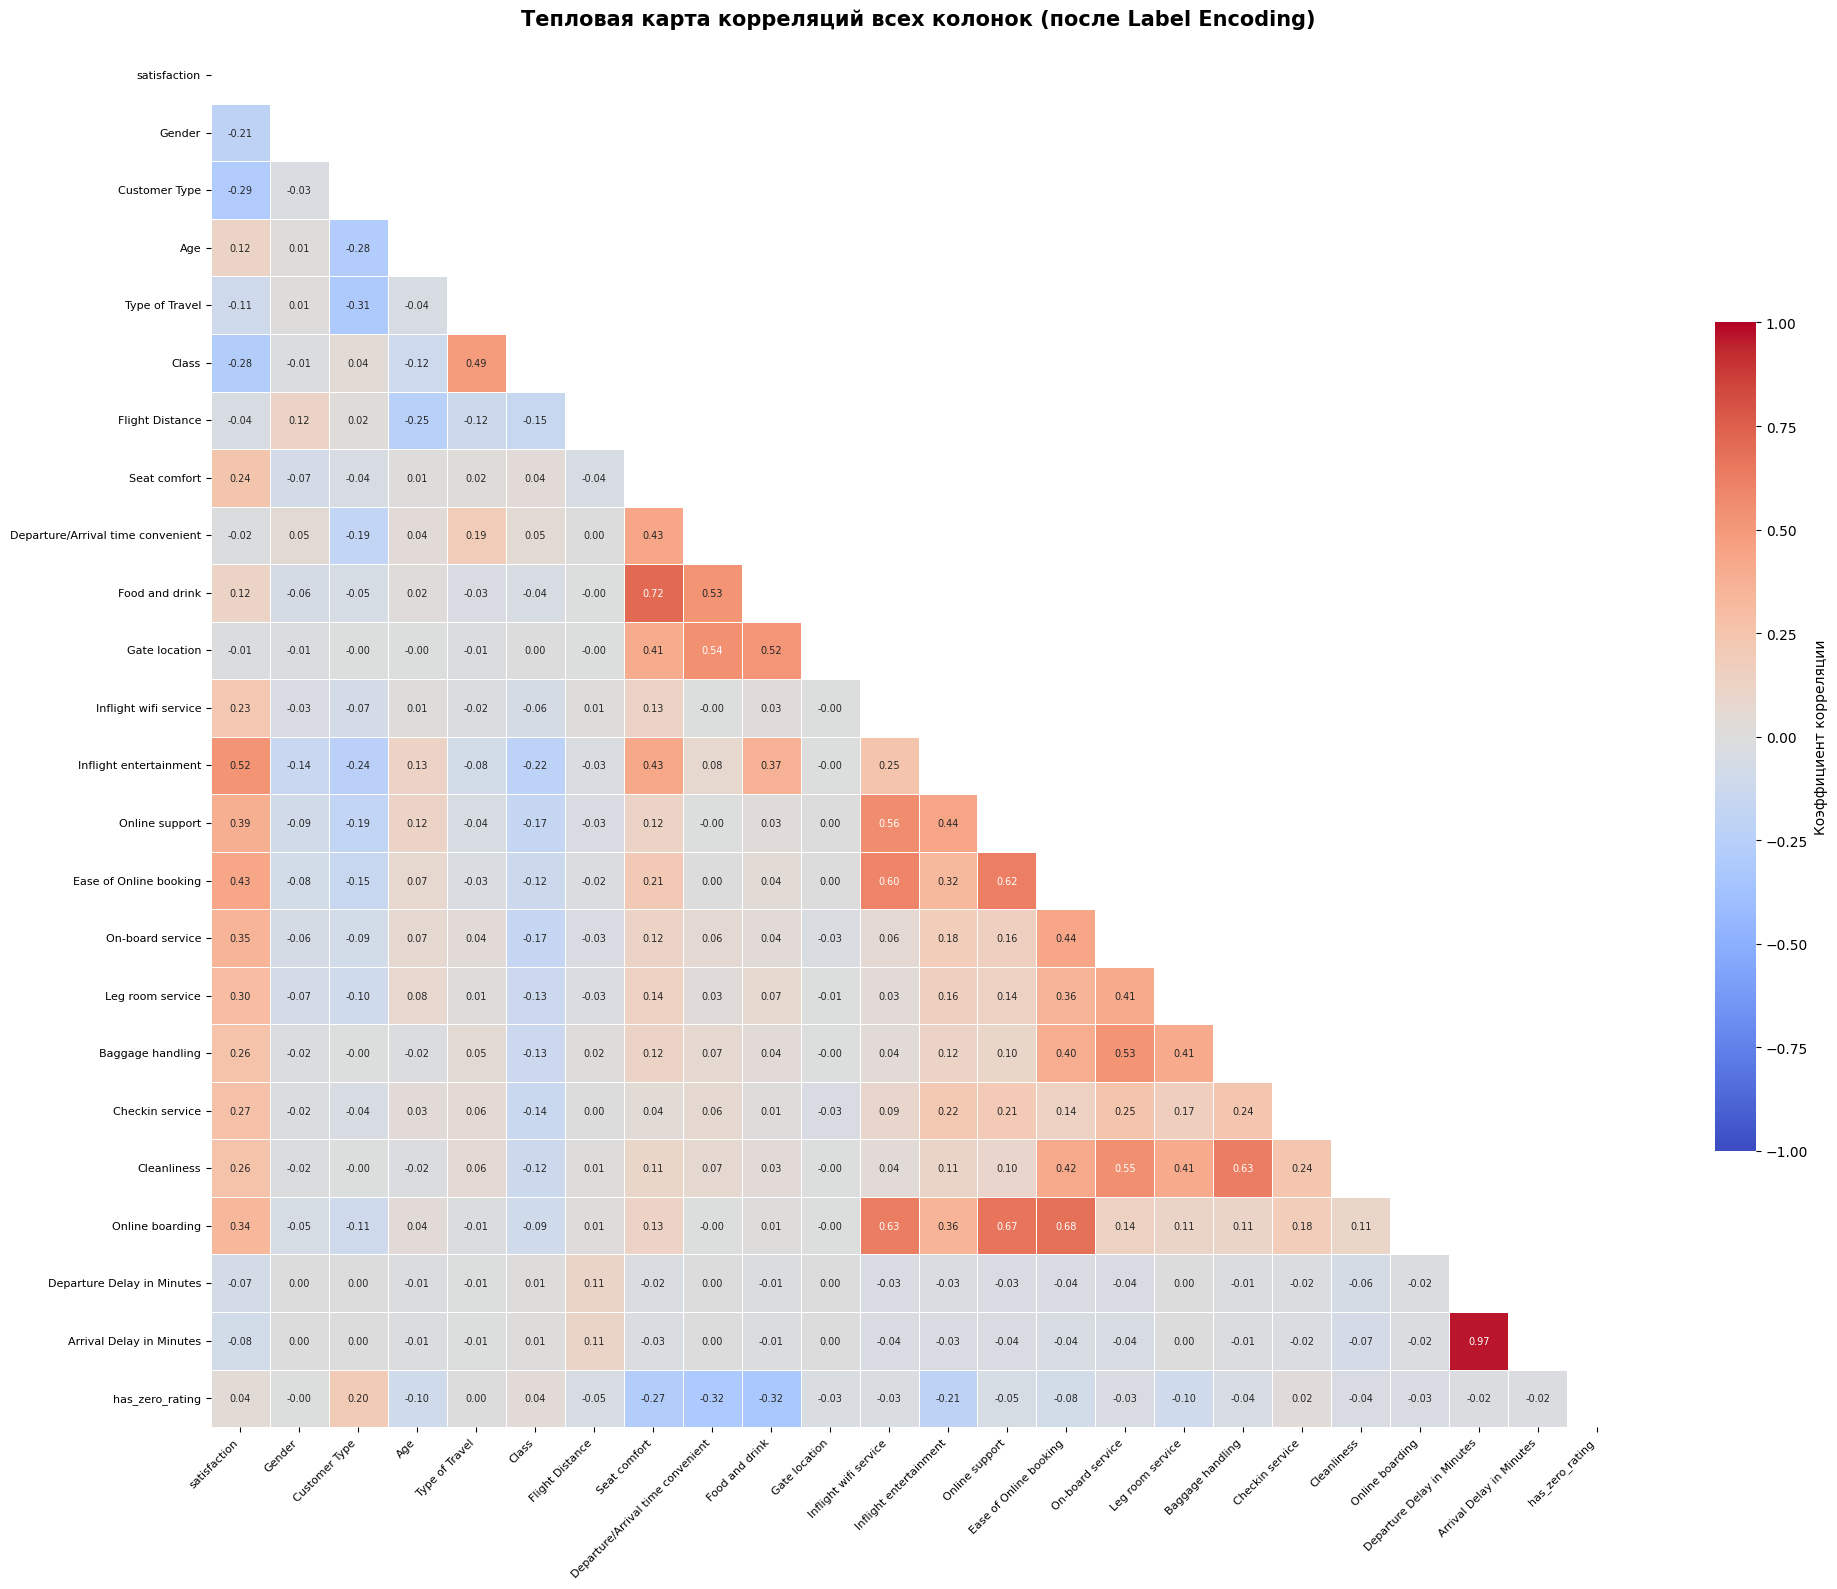

In [35]:
# Тепловая карта
plt.figure(figsize=(20, 16))

corr = df_encoded.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    linecolor='white',
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.6, 'label': 'Коэффициент корреляции'}
)

plt.title('Тепловая карта корреляций всех колонок (после Label Encoding)',
          fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [36]:
service_cols = [
    'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink',
    'Gate location', 'Inflight wifi service', 'Inflight entertainment',
    'Online support', 'Ease of Online booking', 'On-board service',
    'Leg room service', 'Baggage handling', 'Checkin service',
    'Cleanliness', 'Online boarding'
]

df['mean_service_score'] = df[service_cols].mean(axis=1)
df_encoded['mean_service_score'] = df['mean_service_score'].values

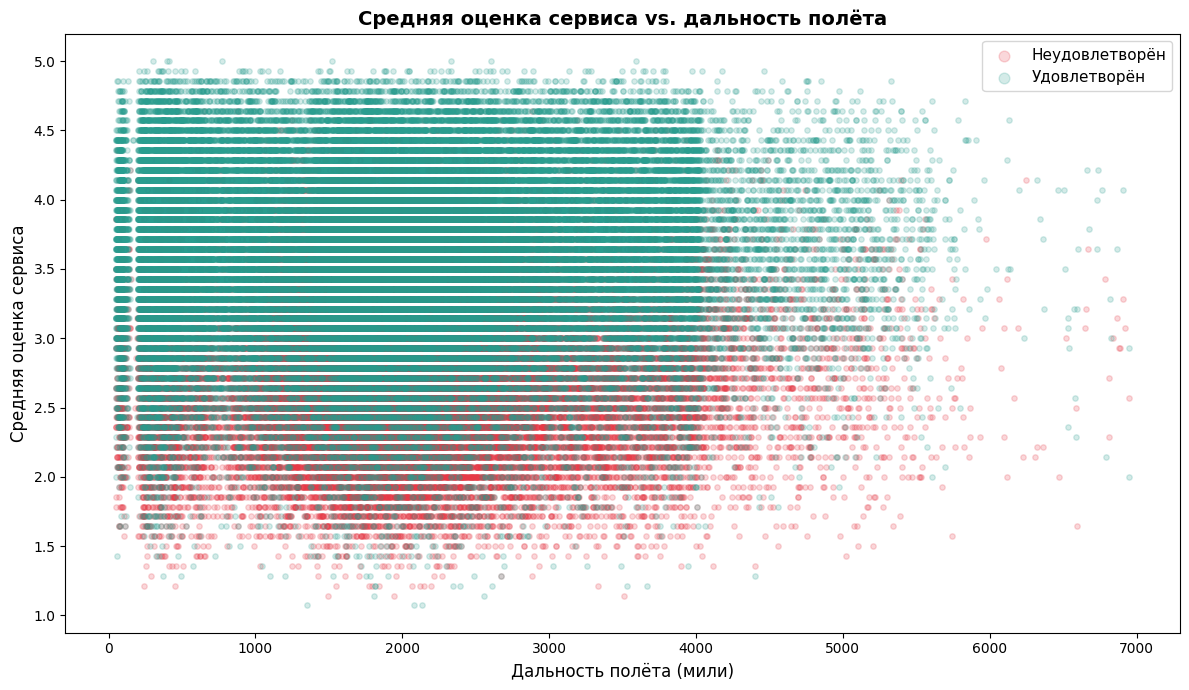

In [37]:
fig, ax = plt.subplots(figsize=(12, 7))

satisfied    = df_encoded[df_encoded['satisfaction'] == 1]
dissatisfied = df_encoded[df_encoded['satisfaction'] == 0]

ax.scatter(
    dissatisfied['Flight Distance'], dissatisfied['mean_service_score'],
    color='#e63946', alpha=0.2, s=15, label='Неудовлетворён'
)

ax.scatter(
    satisfied['Flight Distance'], satisfied['mean_service_score'],
    color='#2a9d8f', alpha=0.2, s=15, label='Удовлетворён'
)

ax.set_xlabel('Дальность полёта (мили)', fontsize=12)
ax.set_ylabel('Средняя оценка сервиса', fontsize=12)
ax.set_title('Средняя оценка сервиса vs. дальность полёта', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, markerscale=2)
plt.tight_layout()
plt.show()

Видим, что начиная с некоторого значения дальность полета выступает фактором, который усиливает раздражение недостатками авиакомпании, хотя напрямую корреляция удовлетворенности с дальностью мала.

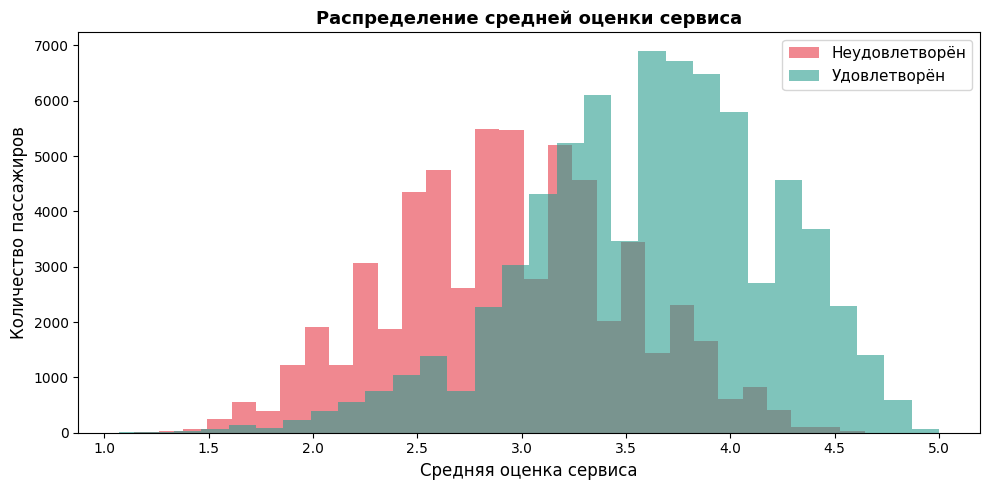

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(dissatisfied['mean_service_score'], bins=30, color='#e63946', alpha=0.6, label='Неудовлетворён')
ax.hist(satisfied['mean_service_score'], bins=30, color='#2a9d8f', alpha=0.6, label='Удовлетворён')
ax.set_xlabel('Средняя оценка сервиса', fontsize=12)
ax.set_ylabel('Количество пассажиров', fontsize=12)
ax.set_title('Распределение средней оценки сервиса', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

И удовлетворенность и неудовлетворенность представляют собой нормальное распределение

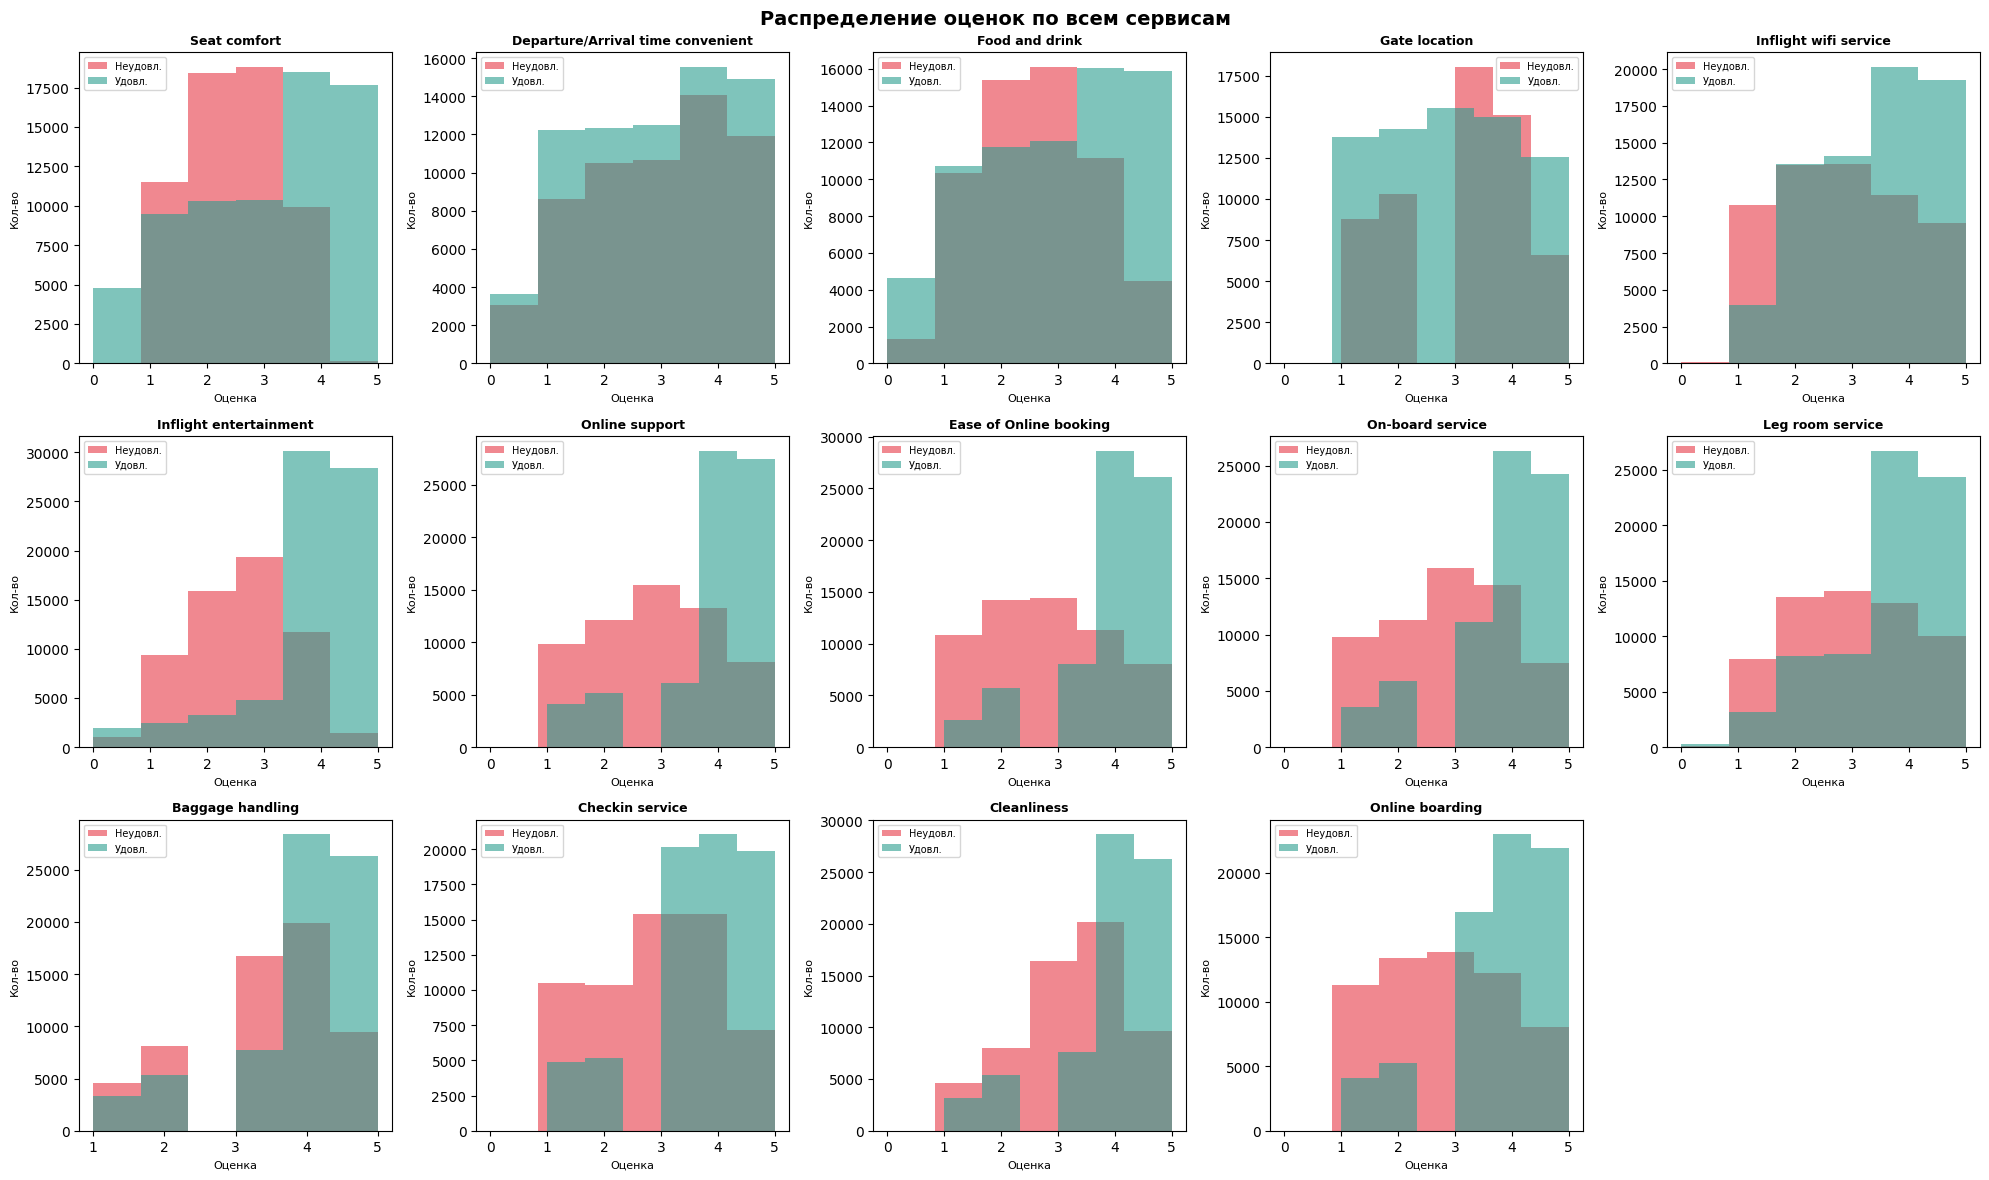

In [39]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()
for i, col in enumerate(service_cols):
    axes[i].hist(dissatisfied[col], bins=6, color='#e63946', alpha=0.6, label='Неудовл.')
    axes[i].hist(satisfied[col], bins=6, color='#2a9d8f', alpha=0.6, label='Удовл.')
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Оценка', fontsize=8)
    axes[i].set_ylabel('Кол-во', fontsize=8)
    axes[i].legend(fontsize=7)

for j in range(len(service_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Распределение оценок по всем сервисам', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

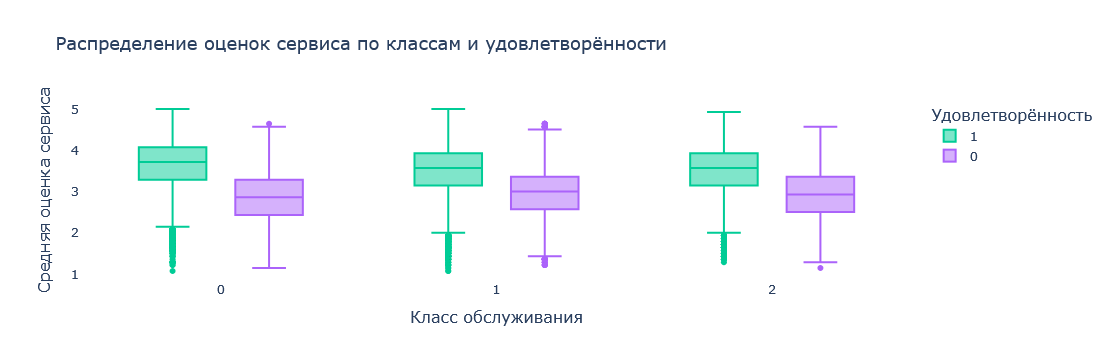

In [40]:
import plotly.express as px

fig = px.box(
    df,
    x='Class',
    y='mean_service_score',
    color='satisfaction',
    points='outliers',
    color_discrete_map={'satisfied': '#2a9d8f', 'neutral or dissatisfied': '#e63946'},
    labels={
        'Class': 'Класс обслуживания',
        'mean_service_score': 'Средняя оценка сервиса',
        'satisfaction': 'Удовлетворённость'
    },
    title='Распределение оценок сервиса по классам и удовлетворённости'
)

fig.update_layout(
    plot_bgcolor='white',
    font=dict(size=13),
    legend_title_text='Удовлетворённость'
)

fig.show()

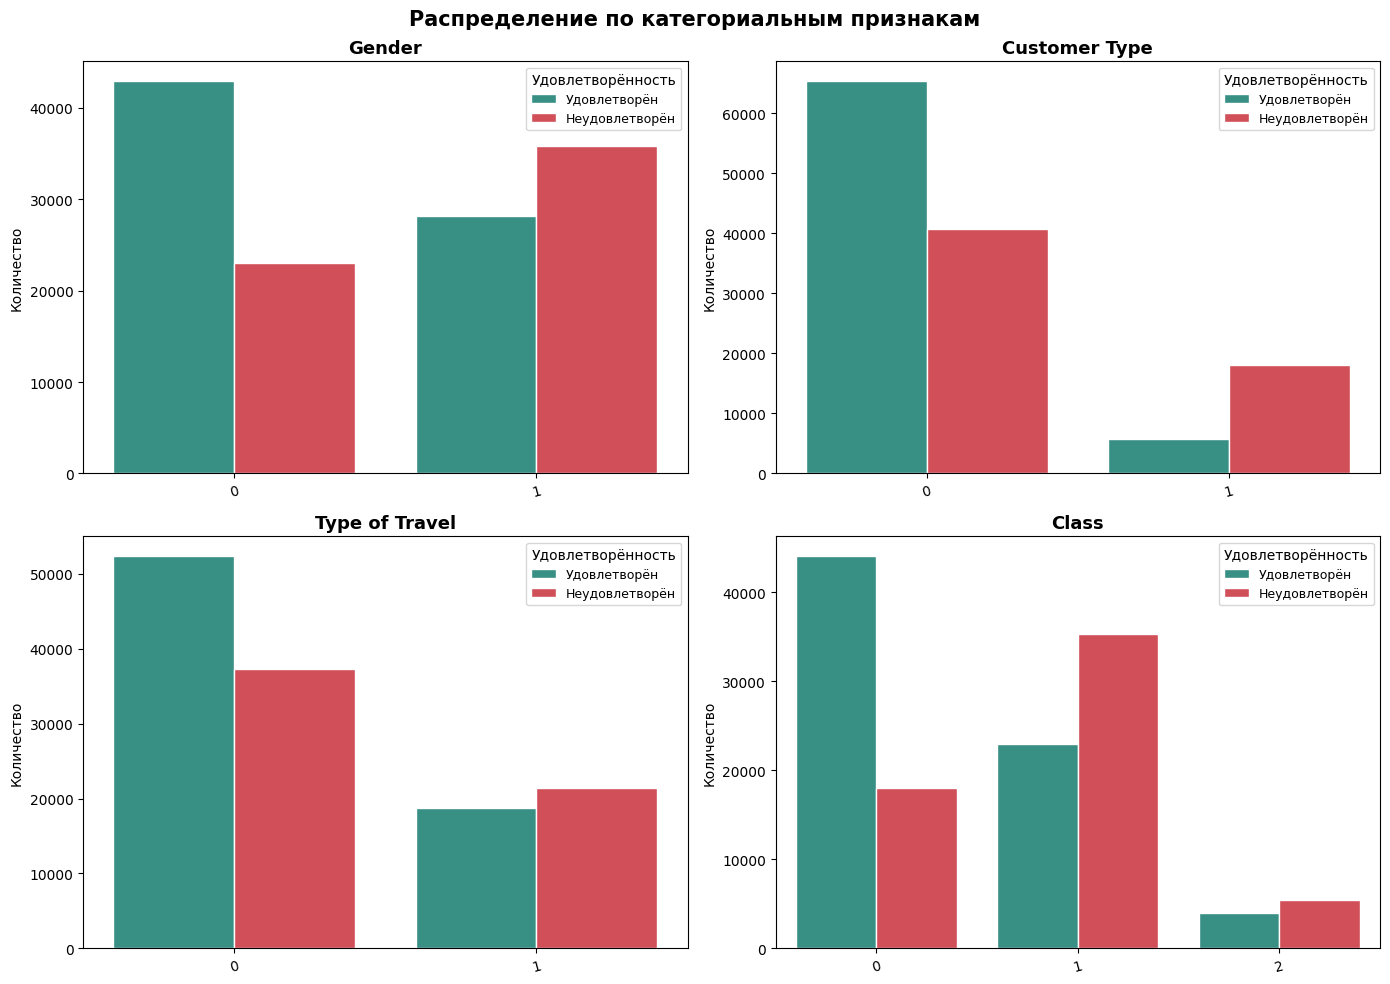

In [41]:
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

df_plot = df_encoded.copy()
df_plot['satisfaction'] = df_plot['satisfaction'].map({0: 'Неудовлетворён', 1: 'Удовлетворён'})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df_plot,
        x=col,
        hue='satisfaction',
        palette={'Удовлетворён': '#2a9d8f', 'Неудовлетворён': '#e63946'},
        ax=axes[i],
        edgecolor='white'
    )
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Количество', fontsize=10)
    axes[i].legend(title='Удовлетворённость', fontsize=9)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Распределение по категориальным признакам', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Итоговые выводы

**Что я понял про датасет:**
- Таргет `satisfaction` бинарный и относительно сбалансирован.
- Возраст распределён близко к нормальному (mean ≈ median), поэтому заполнение пропусков средним безопасно.
- `Arrival Delay in Minutes` сильно скошен вправо: большинство задержек малы, единичные — очень большие.
- `Flight Distance` имеет правую асимметрию (зависит от географии маршрутов).
- Нулевые оценки сервисов - отдельный сигнал (фича `has_zero_rating`).
- Многие сервисные оценки сильно коррелируют между собой (общий «уровень довольства»).
- Средняя оценка сервиса (`mean_service_score`) - разделитель удовлетворённых и нет.
- Категориальные признаки (Class, Type of Travel) заметно связаны с таргетом.
- Дубликатов нет; типы данных адекватны после кодирования.

**Гипотезы/наблюдения:**
- Business-класс и Business-travel дают более высокую удовлетворённость.
- На длинных рейсах слабый сервис сильнее бьёт по удовлетворённости (эффект усиления).
- Хотя бы один ноль в оценках резко повышает шанс «dissatisfied».
- Большие задержки прибытия - выбросы, но их влияние на таргет умереннее, чем у сервиса.